In [1]:
import pandas as pd 
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

os.chdir(r'C:\Users\DAY\Desktop\DIPLOMADO_ANALISIS_DE_DATOS')

df=pd.read_csv('ANalista de Datos M43 - Housing.csv')

In [2]:
#Validar cuantas celdas en total son nulas
print("Existe ", df.isnull().sum().sum(),"valores nulos")

Existe  0 valores nulos


In [10]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


In [5]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.000,4766729.248,1870439.616,1750000.000,3430000.000,4340000.000,5740000.000,13300000.000
area,545.000,5150.541,2170.141,1650.000,3600.000,4600.000,6360.000,16200.000
bedrooms,545.000,2.965,0.738,1.000,2.000,3.000,3.000,6.000
bathrooms,545.000,1.286,0.502,1.000,1.000,1.000,2.000,4.000
stories,545.000,1.806,0.867,1.000,1.000,2.000,2.000,4.000
parking,545.000,0.694,0.862,0.000,0.000,0.000,1.000,3.000


In [7]:
df.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

In [8]:
df['mainroad']=df['mainroad'].replace({'yes':1, 'no':0}, regex=True)
df['guestroom']=df['guestroom'].replace({'yes':1, 'no':0}, regex=True)
df['basement']=df['basement'].replace({'yes':1, 'no':0}, regex=True)
df['hotwaterheating']=df['hotwaterheating'].replace({'yes':1, 'no':0}, regex=True)
df['airconditioning']=df['airconditioning'].replace({'yes':1, 'no':0}, regex=True)
df['prefarea']=df['prefarea'].replace({'yes':1, 'no':0}, regex=True)
df['furnishingstatus']=df['furnishingstatus'].replace({'unfurnished':3, 'semifurnished':2, 'furnished':1}, regex=True)

C:\Users\DAY\AppData\Local\Temp\ipykernel_5880\3208618263.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['mainroad']=df['mainroad'].replace({'yes':1, 'no':0}, regex=True)
C:\Users\DAY\AppData\Local\Temp\ipykernel_5880\3208618263.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['guestroom']=df['guestroom'].replace({'yes':1, 'no':0}, regex=True)
C:\Users\DAY\AppData\Local\Temp\ipykernel_5880\3208618263.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retai

In [9]:
df.sample(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
369,3675000,3600,2,1,1,1,0,0,0,0,0,0,1
102,6195000,5500,3,2,4,1,1,0,0,1,1,0,1
303,4200000,4500,3,1,1,1,0,1,0,0,0,0,1
202,4900000,4120,2,1,1,1,0,1,0,0,1,0,1
83,6580000,6000,3,2,4,1,0,0,0,1,0,0,1
532,2135000,3000,2,1,1,0,0,0,0,0,0,0,3
263,4410000,3968,3,1,2,0,0,0,0,0,0,0,1
399,3500000,7350,2,1,1,1,0,0,0,0,1,0,1
204,4900000,4770,3,1,1,1,1,1,0,0,0,0,1
36,8043000,7482,3,2,3,1,0,0,1,0,1,1,1


In [13]:
df["area_per_bedroom"] = df["area"] / df["bedrooms"]
df["bath_per_bedroom"] = df["bathrooms"] / df["bedrooms"]
df["area_per_story"] = df["area"] / df["stories"]

In [14]:
df[["area", "bedrooms", "bathrooms", "stories", "area_per_bedroom", "bath_per_bedroom", "area_per_story"]].head()

,area,bedrooms,bathrooms,stories,area_per_bedroom,bath_per_bedroom,area_per_story
0,7420,4,2,3,1855.000,0.500,2473.333
1,8960,4,4,4,2240.000,1.000,2240.000
2,9960,3,2,2,3320.000,0.667,4980.000
3,7500,4,2,2,1875.000,0.500,3750.000
4,7420,4,1,2,1855.000,0.250,3710.000


In [15]:
print(df[["area_per_bedroom", "bath_per_bedroom", "area_per_story"]].isnull().sum())
print(np.isinf(df[["area_per_bedroom", "bath_per_bedroom", "area_per_story"]]).sum())

area_per_bedroom    0
bath_per_bedroom    0
area_per_story      0
dtype: int64
area_per_bedroom    0
bath_per_bedroom    0
area_per_story      0
dtype: int64


### Generación de variables dummy

In [16]:
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

In [17]:
#Variable dependiente e independiente
X = df.drop(columns=["price"])
y = df["price"]

In [18]:
#Dividimos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)


In [ ]:
#Evitamos errores por valores
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [20]:
from sklearn.linear_model import LinearRegression

regression_model = LinearRegression()
regression_model.fit(x_train_scaled, y_train)

LinearRegression()

In [ ]:
#REalizamos predicciones
predictions = regression_model.predict(x_test_scaled)

In [22]:
#Evaluamos el modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mae

849381.4926395485

In [23]:
mse = mean_squared_error(y_test, predictions)
mse

1352079631710.432

In [24]:
rmse = np.sqrt(mse)
rmse

np.float64(1162789.5904721678)

In [25]:
r2 = r2_score(y_test, predictions)
r2

0.6678292985658061

In [27]:
#Comparacion de valores reales vs predicciones
comparison = pd.DataFrame({"Real": y_test,"Predicción": predictions})

comparison.head(10)

,Real,Predicción
62,7070000,6238907.838
247,4550000,6333236.917
142,5600000,6787428.499
107,6125000,5544336.070
483,2940000,4406930.597
351,3780000,3054763.898
516,2450000,2685875.487
47,7490000,7308390.986
481,2940000,2402115.805
90,6440000,4619108.074


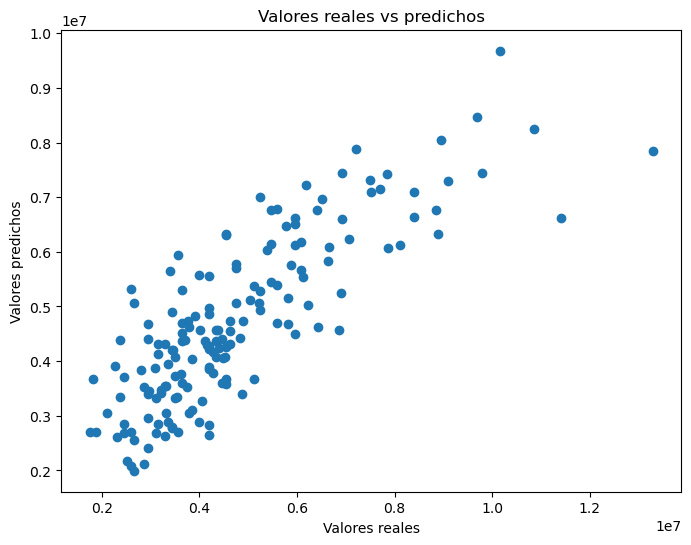

In [28]:
#Visualización
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs predichos")
plt.show()

In [30]:
coeff_data = pd.DataFrame({"Variable": x_train.columns,"Coeficiente": regression_model.coef_})

coeff_data.sort_values(by="Coeficiente", ascending=False).head(10)

,Variable,Coeficiente
0,area,792611.094
2,bathrooms,580487.329
3,stories,374304.065
8,airconditioning,287794.357
6,basement,263971.736
9,parking,233224.531
10,prefarea,217095.044
7,hotwaterheating,171904.670
4,mainroad,166095.709
5,guestroom,99288.308


In [31]:
coeff_data.sort_values(by="Coeficiente", ascending=True).head(10)

,Variable,Coeficiente
11,area_per_bedroom,-180316.309
14,furnishingstatus_3,-166114.380
1,bedrooms,-119981.329
13,area_per_story,-106193.990
12,bath_per_bedroom,-71537.465
5,guestroom,99288.308
4,mainroad,166095.709
7,hotwaterheating,171904.670
10,prefarea,217095.044
9,parking,233224.531


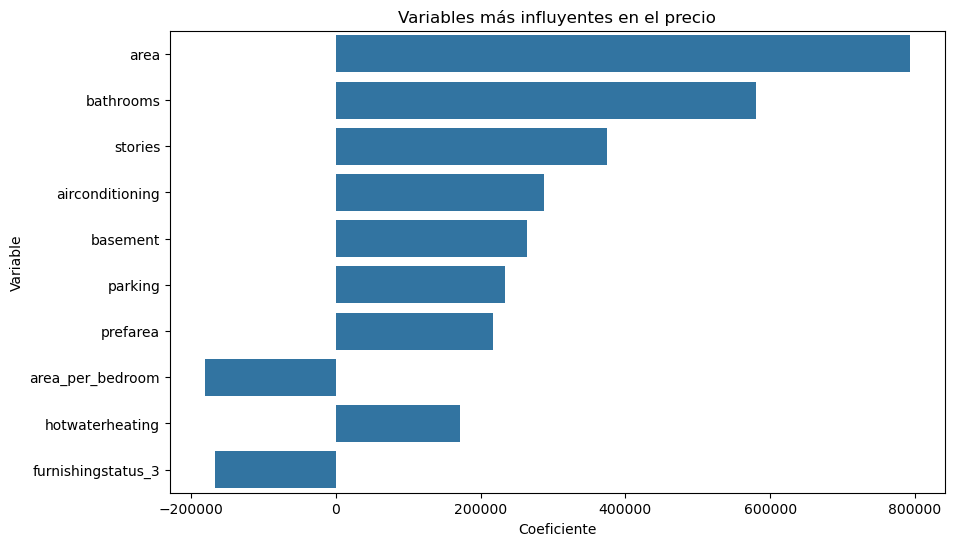

In [32]:
top_features = coeff_data.reindex(coeff_data["Coeficiente"].abs().sort_values(ascending=False).index).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_features, x="Coeficiente", y="Variable")
plt.title("Variables más influyentes en el precio")
plt.show()

## Conclusión

- A partir del análisis realizado y del modelo de regresión lineal aplicado, se observa que el área de la vivienda es la variable que más influye en el precio, lo cual es lógico ya que las casas más grandes suelen tener mayor valor. También se identificó que variables como el número de baños, el número de pisos, el aire acondicionado y el estacionamiento tienen una influencia positiva en el precio de las casas.

- Esto indica que características relacionadas con el tamaño, la comodidad y los servicios de la vivienda son factores importantes para determinar su valor. En general, el modelo permite identificar qué variables tienen mayor impacto en el precio y puede servir como una herramienta para estimar el valor de una vivienda a partir de sus características.